In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Span

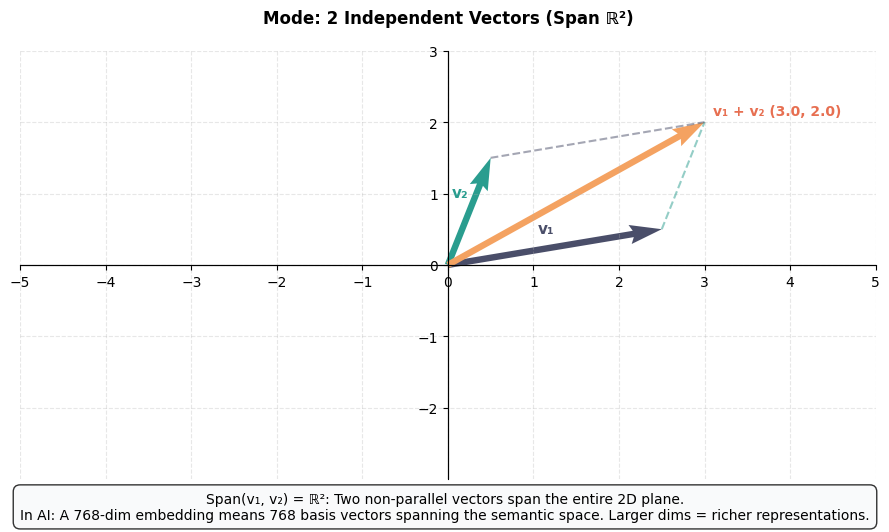

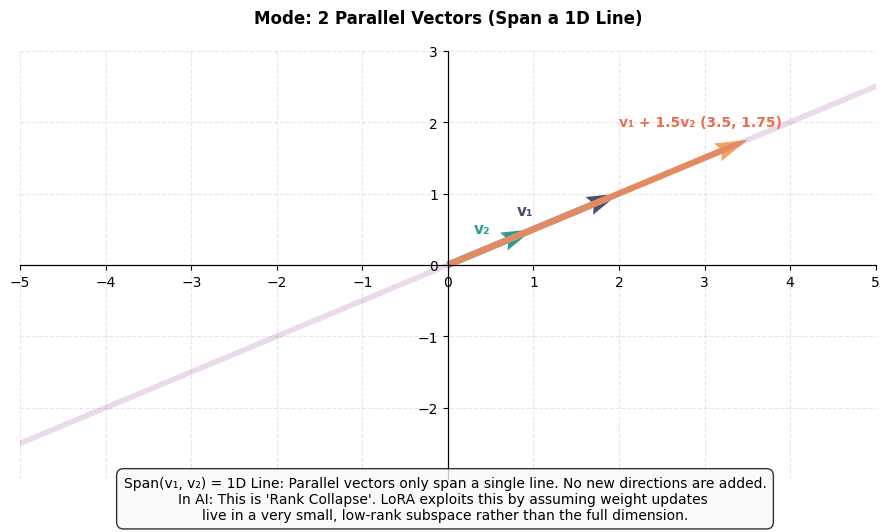

In [2]:
def setup_plot(title, ai_context):
    """Helper function to setup clean axes and context text."""
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.set_xlim(-5, 5)
    ax.set_ylim(-3, 3)
    ax.axhline(0, color='grey', lw=1, alpha=0.5)
    ax.axvline(0, color='grey', lw=1, alpha=0.5)
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.set_xticks(np.arange(-5, 6, 1))
    ax.set_yticks(np.arange(-2, 4, 1))
    
    ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
    
    # Add AI Context at the bottom
    plt.figtext(0.5, -0.05, ai_context, ha="center", fontsize=10, 
                bbox={"facecolor":"#f8f9fa", "alpha":0.8, "pad":8, "boxstyle":"round,pad=0.5"})
    
    return fig, ax

def plot_vector(ax, vec, color, label):
    """Helper function to plot a single vector."""
    ax.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1, color=color)
    ax.text(vec[0]*0.5 - 0.2, vec[1]*0.5 + 0.2, label, color=color, fontsize=11, fontweight='bold')

# ==========================================
# FLOW 1: INDEPENDENT VECTORS (Span R^2)
# ==========================================
text_independent = (
    "Span(v₁, v₂) = ℝ²: Two non-parallel vectors span the entire 2D plane.\n"
    "In AI: A 768-dim embedding means 768 basis vectors spanning the semantic space. "
    "Larger dims = richer representations."
)
fig1, ax1 = setup_plot("Mode: 2 Independent Vectors (Span ℝ²)", text_independent)

# Vectors
v1_ind = np.array([2.5, 0.5])
v2_ind = np.array([0.5, 1.5])
c1, c2 = 1.0, 1.0
res_ind = c1*v1_ind + c2*v2_ind

# Plotting
plot_vector(ax1, v1_ind, '#4A4E69', 'v₁')
plot_vector(ax1, v2_ind, '#2A9D8F', 'v₂')

# Resultant vector
ax1.quiver(0, 0, res_ind[0], res_ind[1], angles='xy', scale_units='xy', scale=1, color='#F4A261')
ax1.text(res_ind[0] + 0.1, res_ind[1] + 0.1, f"v₁ + v₂ ({res_ind[0]}, {res_ind[1]})", color='#E76F51', fontweight='bold')

# Parallelogram lines
ax1.plot([v1_ind[0], res_ind[0]], [v1_ind[1], res_ind[1]], ls='--', color='#2A9D8F', alpha=0.5)
ax1.plot([v2_ind[0], res_ind[0]], [v2_ind[1], res_ind[1]], ls='--', color='#4A4E69', alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# FLOW 2: PARALLEL VECTORS (Span 1D / Rank Collapse)
# ==========================================
text_dependent = (
    "Span(v₁, v₂) = 1D Line: Parallel vectors only span a single line. No new directions are added.\n"
    "In AI: This is 'Rank Collapse'. LoRA exploits this by assuming weight updates \n"
    "live in a very small, low-rank subspace rather than the full dimension."
)
fig2, ax2 = setup_plot("Mode: 2 Parallel Vectors (Span a 1D Line)", text_dependent)

# Vectors
v1_dep = np.array([2.0, 1.0])
v2_dep = np.array([1.0, 0.5]) # Parallel to v1
c1_dep, c2_dep = 1.0, 1.5
res_dep = c1_dep*v1_dep + c2_dep*v2_dep

# Span Line (background)
x_line = np.linspace(-5, 5, 100)
y_line = (v1_dep[1]/v1_dep[0]) * x_line
ax2.plot(x_line, y_line, color='purple', alpha=0.15, lw=4, label="1D Span")

# Plotting
plot_vector(ax2, v1_dep, '#4A4E69', 'v₁')
plot_vector(ax2, v2_dep, '#2A9D8F', 'v₂')

# Resultant vector
ax2.quiver(0, 0, res_dep[0], res_dep[1], angles='xy', scale_units='xy', scale=1, color='#F4A261')
ax2.text(res_dep[0] - 1.5, res_dep[1] + 0.2, f"v₁ + 1.5v₂ ({res_dep[0]}, {res_dep[1]})", color='#E76F51', fontweight='bold')

plt.tight_layout()
plt.show()

# Basis

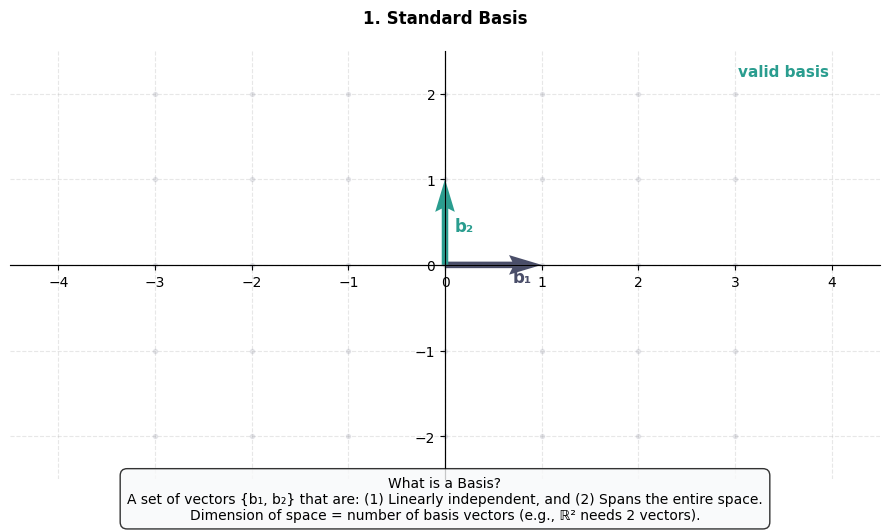

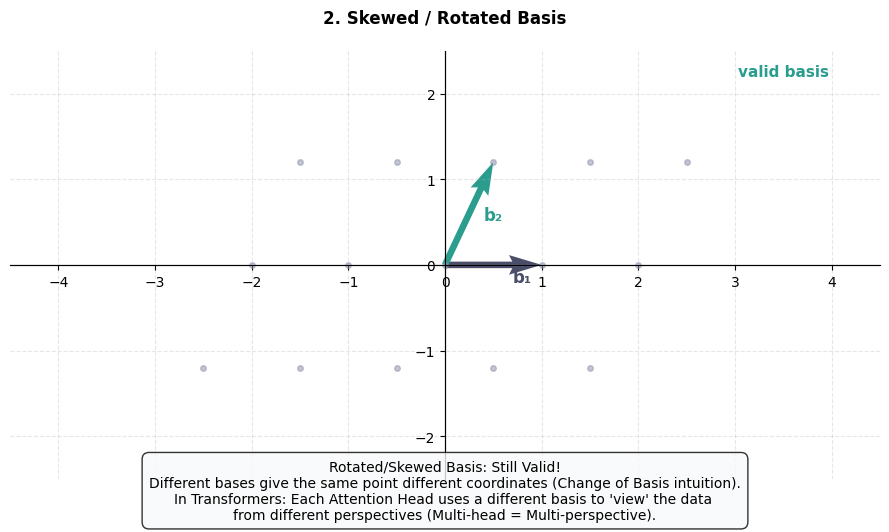

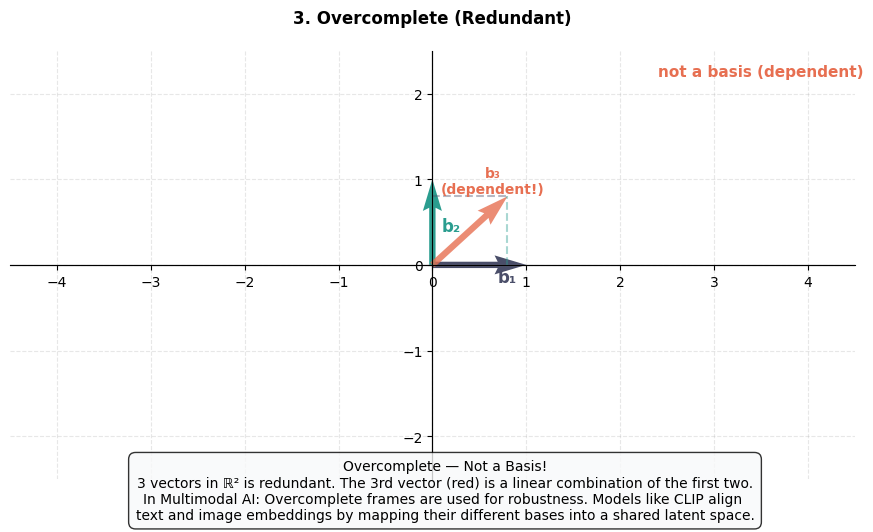

In [3]:
def setup_basis_plot(title, ai_context, is_valid=True):
    """Helper function to setup clean axes for Basis visualization."""
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-2.5, 2.5)
    ax.axhline(0, color='grey', lw=1, alpha=0.5)
    ax.axvline(0, color='grey', lw=1, alpha=0.5)
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.set_xticks(np.arange(-4, 5, 1))
    ax.set_yticks(np.arange(-2, 3, 1))
    
    ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
    
    # Status text (Top Right)
    status_text = "valid basis" if is_valid else "not a basis (dependent)"
    status_color = "#2A9D8F" if is_valid else "#E76F51"
    ax.text(3.5, 2.2, status_text, color=status_color, fontsize=11, fontweight='bold', ha='center')
    
    # Add AI Context at the bottom
    plt.figtext(0.5, -0.05, ai_context, ha="center", fontsize=10, 
                bbox={"facecolor":"#f8f9fa", "alpha":0.8, "pad":8, "boxstyle":"round,pad=0.5"})
    
    return fig, ax

def plot_vector(ax, vec, color, label, ls='-'):
    """Helper function to plot a single vector."""
    ax.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1, color=color, ls=ls)
    # Offset label slightly for better visibility
    ax.text(vec[0]*0.6 + 0.1, vec[1]*0.6 - 0.2, label, color=color, fontsize=12, fontweight='bold')

# ==========================================
# FLOW 1: STANDARD BASIS
# ==========================================
text_standard = (
    "What is a Basis?\n"
    "A set of vectors {b₁, b₂} that are: (1) Linearly independent, and (2) Spans the entire space.\n"
    "Dimension of space = number of basis vectors (e.g., ℝ² needs 2 vectors)."
)
fig1, ax1 = setup_basis_plot("1. Standard Basis", text_standard, is_valid=True)

b1_std = np.array([1, 0])
b2_std = np.array([0, 1])

plot_vector(ax1, b1_std, '#4A4E69', 'b₁')
plot_vector(ax1, b2_std, '#2A9D8F', 'b₂')

# Draw some faint grid points reachable by integers
for i in range(-3, 4):
    for j in range(-2, 3):
        ax1.plot(i, j, marker='o', markersize=3, color='#4A4E69', alpha=0.1)

plt.tight_layout()
plt.show()

# ==========================================
# FLOW 2: SKEWED / ROTATED BASIS
# ==========================================
text_rotated = (
    "Rotated/Skewed Basis: Still Valid!\n"
    "Different bases give the same point different coordinates (Change of Basis intuition).\n"
    "In Transformers: Each Attention Head uses a different basis to 'view' the data \n"
    "from different perspectives (Multi-head = Multi-perspective)."
)
fig2, ax2 = setup_basis_plot("2. Skewed / Rotated Basis", text_rotated, is_valid=True)

# Skewed basis
b1_skew = np.array([1, 0])
b2_skew = np.array([0.5, 1.2])

plot_vector(ax2, b1_skew, '#4A4E69', 'b₁')
plot_vector(ax2, b2_skew, '#2A9D8F', 'b₂')

# Draw the skewed grid points
for i in range(-2, 3):
    for j in range(-1, 2):
        pt = i*b1_skew + j*b2_skew
        if -4 <= pt[0] <= 4 and -2 <= pt[1] <= 2:
            ax2.plot(pt[0], pt[1], marker='o', markersize=4, color='#8A8DAB', alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# FLOW 3: OVERCOMPLETE (NOT A BASIS)
# ==========================================
text_overcomplete = (
    "Overcomplete — Not a Basis!\n"
    "3 vectors in ℝ² is redundant. The 3rd vector (red) is a linear combination of the first two.\n"
    "In Multimodal AI: Overcomplete frames are used for robustness. Models like CLIP align \n"
    "text and image embeddings by mapping their different bases into a shared latent space."
)
fig3, ax3 = setup_basis_plot("3. Overcomplete (Redundant)", text_overcomplete, is_valid=False)

b1_ovr = np.array([1, 0])
b2_ovr = np.array([0, 1])
b3_ovr = np.array([0.8, 0.8]) # The dependent vector

plot_vector(ax3, b1_ovr, '#4A4E69', 'b₁')
plot_vector(ax3, b2_ovr, '#2A9D8F', 'b₂')
# Plotting the redundant vector with a dashed line appearance conceptually (using quiver)
ax3.quiver(0, 0, b3_ovr[0], b3_ovr[1], angles='xy', scale_units='xy', scale=1, color='#E76F51', alpha=0.8)
ax3.text(b3_ovr[0]*0.8, b3_ovr[1]*0.8 + 0.2, 'b₃\n(dependent!)', color='#E76F51', fontsize=10, fontweight='bold', ha='center')

# Show how b3 is made of b1 and b2
ax3.plot([b3_ovr[0], b3_ovr[0]], [0, b3_ovr[1]], ls='--', color='#2A9D8F', alpha=0.4)
ax3.plot([0, b3_ovr[0]], [b3_ovr[1], b3_ovr[1]], ls='--', color='#4A4E69', alpha=0.4)

plt.tight_layout()
plt.show()